In [2]:
import pandas as pd
import csv

In [3]:
df = pd.read_csv("Main2_combined.csv", delimiter = ',', encoding='utf-8')

In [4]:
df.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,chair,final_tag
0,ParlaMint-SI_2013-10-21-SDZ6-Redna-18.u63,Hvala. Besedo dajem gospodu Samu Omerzelu.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,NaN
1,ParlaMint-SI_2010-12-23-SDZ5-Izredna-36.u69,Hvala lepa. Končali smo s predstavitvijo stali...,N_Neutral,N_Neutral,Could be negative,NaN,NaN,NaN,True,NaN
2,ParlaMint-SI_2020-10-15-SDZ8-Izredna-46.u33,"Glejte, gospa [[…]] [[oglašanje iz dvorane]]",N_Neutral,P_Neutral,We don't know what this is but negative.,NaN,NaN,NaN,True,NaN
3,ParlaMint-SI_2010-11-17-SDZ5-Redna-22.u106,"Hvala lepa. Glasujemo. Prekinjam. Prosim, gosp...",P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,NaN
4,ParlaMint-SI_2005-10-26-SDZ4-Redna-10.u151,Hvala lepa. In še kot zadnjega vabim k besedi ...,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,NaN


# 6-level schema analysis (Cohen's Kappa (κ))

In [5]:
from sklearn.metrics import cohen_kappa_score
annotator1 = df['tag_tamara']
annotator2 = df['tag_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.6691162325420337)

# κ for non-procedural and procedural speech


In [6]:
df_non = df[df['chair'] != True]

In [7]:
df_procedural = df[df['chair'] == True]

In [8]:
#df_procedural

In [9]:
annotator1 = df_non['tag_tamara']
annotator2 = df_non['tag_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.4747404844290657)

In [10]:
annotator1_procedural = df_procedural['tag_tamara']
annotator2_procedural = df_procedural['tag_katja']
cohen_kappa_score(annotator1_procedural, annotator2_procedural)

np.float64(0.38636363636363624)

# 3-level analysis (Cohen's Kappa (κ))

In [11]:
df.loc[(df['tag_tamara'] == 'Negative') | (df['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
df.loc[(df['tag_tamara'] == 'Positive') | (df['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
df.loc[(df['tag_tamara'] == 'P_Neutral') | (df['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

In [12]:
df.loc[(df['tag_katja'] == 'Negative') | (df['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
df.loc[(df['tag_katja'] == 'Positive') | (df['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
df.loc[(df['tag_katja'] == 'P_Neutral') | (df['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'

In [12]:
#df

In [13]:
annotator1 = df['sent_tamara']
annotator2 = df['sent_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.841925002195486)

In [14]:
df_non.loc[(df_non['tag_tamara'] == 'Negative') | (df_non['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
df_non.loc[(df_non['tag_tamara'] == 'Positive') | (df_non['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
df_non.loc[(df_non['tag_tamara'] == 'P_Neutral') | (df_non['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

/var/folders/ng/b52w03cd2d31sdjpmc5kyqlh0000gr/T/ipykernel_13842/136232902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non.loc[(df_non['tag_tamara'] == 'Negative') | (df_non['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'


In [15]:
df_non.loc[(df_non['tag_katja'] == 'Negative') | (df_non['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
df_non.loc[(df_non['tag_katja'] == 'Positive') | (df_non['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
df_non.loc[(df_non['tag_katja'] == 'P_Neutral') | (df_non['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'

/var/folders/ng/b52w03cd2d31sdjpmc5kyqlh0000gr/T/ipykernel_13842/4240778448.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non.loc[(df_non['tag_katja'] == 'Negative') | (df_non['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'


In [16]:
annotator1 = df_non['sent_tamara']
annotator2 = df_non['sent_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.6946902654867257)

# Generating dataset for consolidation

Adding new column for the final annotation, provided with consolidation

Note: Comment out after consolidation dataset is created

In [15]:
#df['final_tag'] = df.apply(lambda row: row['tag_tamara'] if row['tag_tamara'] == row['tag_katja'] else None, axis=1)
#df.to_csv("Main2_consolidation.csv", encoding = 'utf-8')

# Aggergating Kappa scores

In [17]:
kappa_scores = {
    "6-level":{
        "full":0.67,
        "non-procedural":0.47
        
    },
    "3-level":{
        "full": 0.84,
        "non-procedural":0.69
    }
}

df_kappa = pd.DataFrame(kappa_scores)

def create_test_df(kappa_scores, test_label):
    df_kappa = pd.DataFrame(kappa_scores).reset_index()
    df_kappa.rename(columns={'index': 'Type'}, inplace=True)
    df_kappa['Phase'] = test_label
    # Reorder columns to place 'Test' before 'Type'
    df_kappa = df_kappa[['Phase', 'Type', '6-level', '3-level']]
    return df_kappa

In [18]:
df_test = create_test_df(kappa_scores, 'Main2')
df_test

,Phase,Type,6-level,3-level
0,Main2,full,0.67,0.84
1,Main2,non-procedural,0.47,0.69


In [19]:
df_test.to_csv("../Kappa_scores_Main2.csv", index=False)

# Label distribution

## Label distribution - final tags

In [19]:
df1 = pd.read_excel("Main2_consolidation.xlsx")
df1.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,chair,final_tag
0,ParlaMint-SI_2013-10-21-SDZ6-Redna-18.u63,Hvala. Besedo dajem gospodu Samu Omerzelu.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,P_Neutral
1,ParlaMint-SI_2010-12-23-SDZ5-Izredna-36.u69,Hvala lepa. Končali smo s predstavitvijo stali...,N_Neutral,N_Neutral,Could be negative,NaN,NaN,NaN,True,N_Neutral
2,ParlaMint-SI_2020-10-15-SDZ8-Izredna-46.u33,"Glejte, gospa [[…]] [[oglašanje iz dvorane]]",N_Neutral,P_Neutral,We don't know what this is but negative.,NaN,NaN,NaN,True,N_Neutral
3,ParlaMint-SI_2010-11-17-SDZ5-Redna-22.u106,"Hvala lepa. Glasujemo. Prekinjam. Prosim, gosp...",P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,P_Neutral
4,ParlaMint-SI_2005-10-26-SDZ4-Redna-10.u151,Hvala lepa. In še kot zadnjega vabim k besedi ...,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,P_Neutral


In [20]:
df1_labels = df1['final_tag'].value_counts()
df1_labels

final_tag
P_Neutral     102
Negative       51
M_Positive     15
N_Neutral      14
Positive       10
M_Negative      8
Name: count, dtype: int64

[]

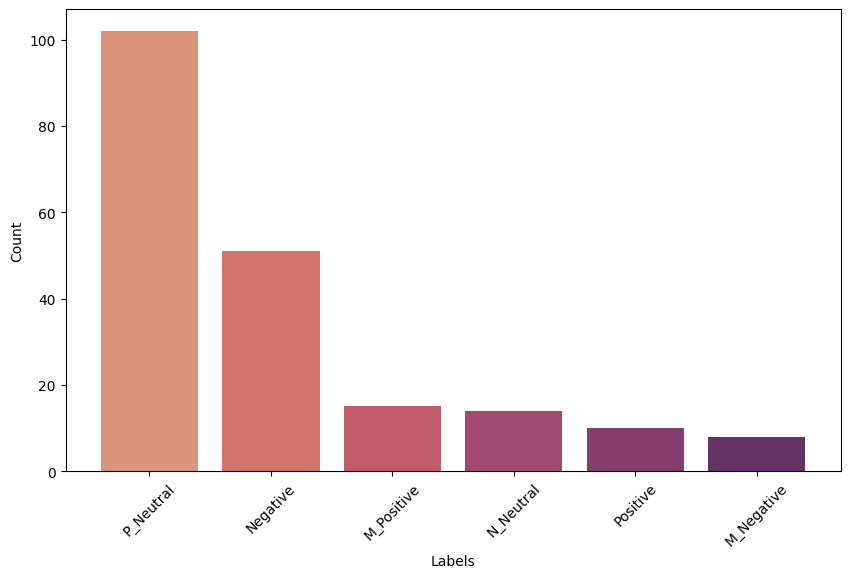

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x=df1_labels.index, y=df1_labels.values, hue=df1_labels.index, palette='flare', legend=False)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.plot()

## Label distribution, non-procedural speeches only

In [22]:
df2 = df1[df1['chair'] != True]
df2_labels = df2['final_tag'].value_counts()
df2_labels

final_tag
Negative      50
M_Positive    15
Positive      10
M_Negative     8
P_Neutral      5
N_Neutral      4
Name: count, dtype: int64

[]

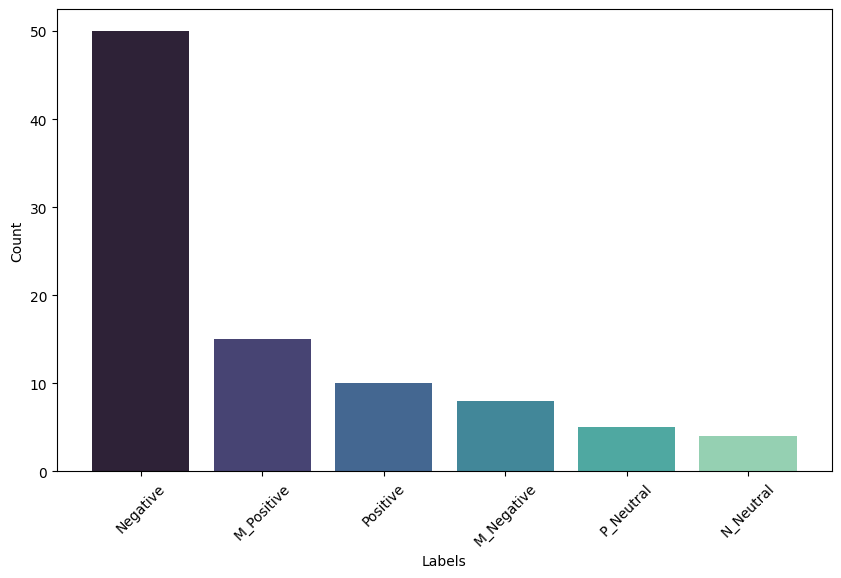

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x=df2_labels.index, y=df2_labels.values, hue=df2_labels.index, palette='mako', legend=False)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.plot()

Label distribution for procedural speech

In [24]:
df3 = df1[df1['chair'] == True]
df3_labels = df3['final_tag'].value_counts()
df3_labels

final_tag
P_Neutral    97
N_Neutral    10
Negative      1
Name: count, dtype: int64

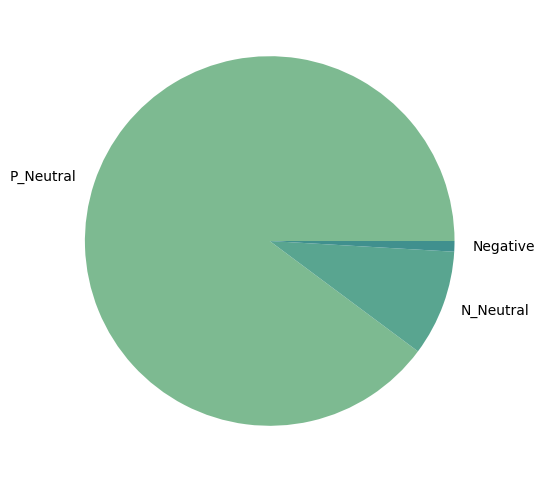

In [25]:
palette = sns.color_palette('crest')
plt.figure(figsize=(10,6))
plt.pie(df3_labels, labels=df3_labels.index, colors=palette)
plt.show()


# Label distribution per annotators

In [26]:
annotator1_labels = df['tag_tamara'].value_counts()
annotator2_labels = df1['tag_katja'].value_counts()
annotators = pd.DataFrame({
    'annotator1': annotator1_labels,
    'annotator2': annotator2_labels
})
#annotators.head()

In [27]:
annotators = annotators.reset_index().rename(columns={'index':'label'})

In [28]:
annotators = annotators.melt(id_vars='label', var_name='annotator', value_name='count')
annotators

,label,annotator,count
0,M_Negative,annotator1,13
1,M_Positive,annotator1,12
2,N_Neutral,annotator1,13
3,Negative,annotator1,45
4,P_Neutral,annotator1,100
5,Positive,annotator1,17
6,M_Negative,annotator2,4
7,M_Positive,annotator2,16
8,N_Neutral,annotator2,5
9,Negative,annotator2,54


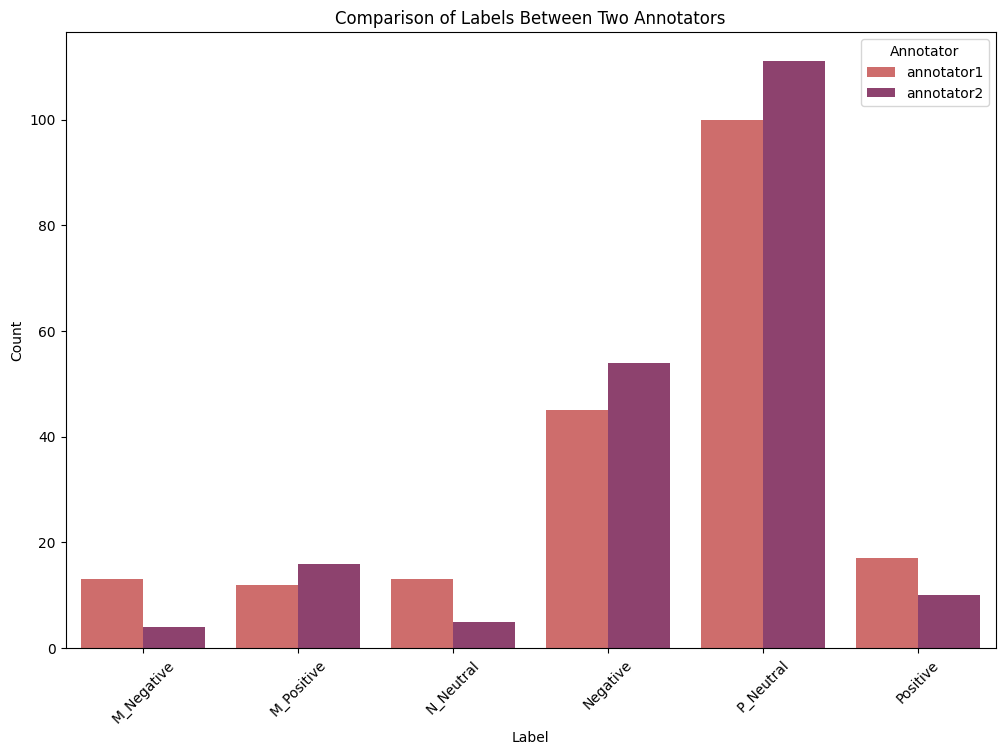

In [29]:
plt.figure(figsize=(12, 8))
sns.barplot(x='label', y='count', hue='annotator', data=annotators, palette='flare')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()

## Label distribution per annotator - non-procedural only

In [30]:
annotator1_labels = df2['tag_tamara'].value_counts()
annotator2_labels = df2['tag_katja'].value_counts()
annotators_non = pd.DataFrame({
    'annotator1': annotator1_labels,
    'annotator2': annotator2_labels
})
#annotators.head()

In [31]:
annotators_non = annotators_non.reset_index().rename(columns={'index':'label'})
annotators_non = annotators_non.melt(id_vars='label', var_name='annotator', value_name='count')
annotators_non

,label,annotator,count
0,M_Negative,annotator1,13
1,M_Positive,annotator1,12
2,N_Neutral,annotator1,3
3,Negative,annotator1,43
4,P_Neutral,annotator1,5
5,Positive,annotator1,16
6,M_Negative,annotator2,4
7,M_Positive,annotator2,16
8,N_Neutral,annotator2,3
9,Negative,annotator2,52


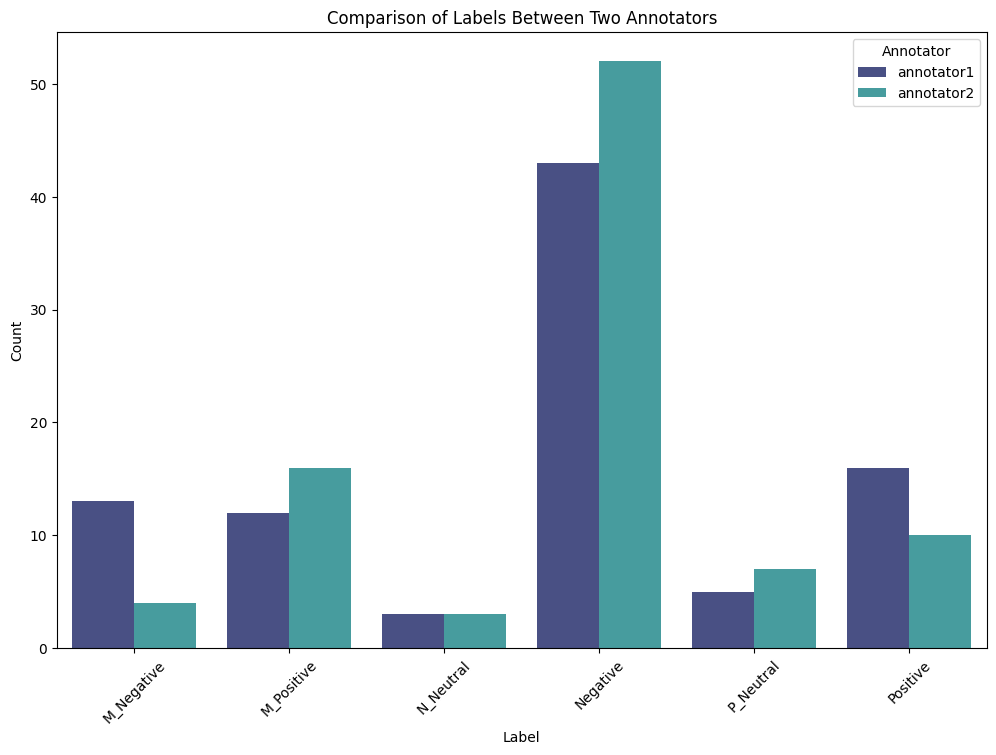

In [32]:
plt.figure(figsize=(12, 8))
sns.barplot(x='label', y='count', hue='annotator', data=annotators_non, palette='mako')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()

# Label distribution - procedural-only

In [33]:
annotator1_procedural = df3['tag_tamara'].value_counts()
annotator2_procedural = df3['tag_katja'].value_counts()
annotators_procedural = pd.DataFrame({
    'annotator1': annotator1_procedural,
    'annotator2': annotator2_procedural 
})
annotators_procedural.head()

,annotator1,annotator2
N_Neutral,10,2.0
Negative,2,2.0
P_Neutral,95,104.0
Positive,1,NaN


In [34]:
procedural = annotators_procedural.reset_index().rename(columns={'index':'label'})
procedural = procedural.melt(id_vars='label', var_name='annotator', value_name='count')
procedural

,label,annotator,count
0,N_Neutral,annotator1,10.0
1,Negative,annotator1,2.0
2,P_Neutral,annotator1,95.0
3,Positive,annotator1,1.0
4,N_Neutral,annotator2,2.0
5,Negative,annotator2,2.0
6,P_Neutral,annotator2,104.0
7,Positive,annotator2,NaN


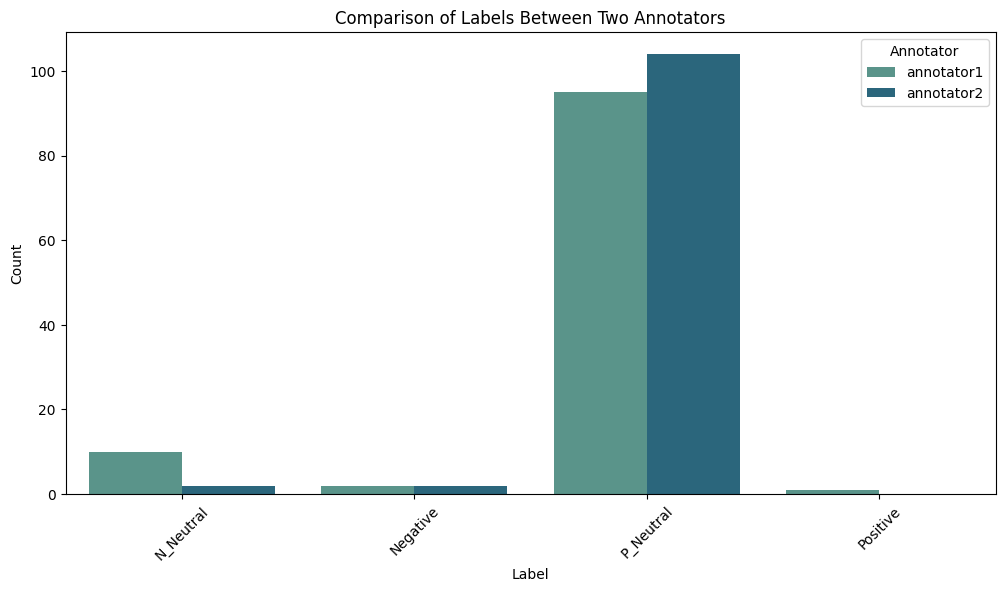

In [35]:
plt.figure(figsize=(12, 6))
sns.barplot(x='label', y='count', hue='annotator', data=procedural, palette='crest')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()

## Consolidation notes:

- 43/200 mismatched annotations (21%)
- Agreement does not equal sentiment (citations! But this is also seen in the annotation. Several examples, where the speaker offers support regarding proposed change, however the speech is very negative.)
- Procedural speech is usually N_Neutral, however, there are some examples of them containing sentiment, either as N_Neutral or pure Negative.
- Most times, several interpretations are possible, noted in the Comments. Often one annotator noted the intepretation that the other annotator used:
Example (Main2 consolidation, no. 184):
	
    Comment Tamara: Presents a new law he supports. **Maybe P_Neutral.** 	
    
    Comment Katja: Presentation of the proposal, while **it could also be Positive**, I think it might be a bit lacking in sentiment to be considered that.